# Воробьев Андрей Павлович, 465440, J3211

# Кейс 7: аддитивная модель по мотивам теоремы Колмогорова
В условии кейса необходимо восстановить зависимость $y = f(x_1, \ldots, x_p) + \varepsilon$ при $x_j \in [0, 1]^p$. Теорема Колмогорова о представлении непрерывной функции утверждает, что $f$ на единичном кубе выражается через суперпозицию функций одного аргумента и сложения. На практике используют упрощённый вариант, аддитивную модель:
$$\hat f(x) = \beta_0 + \sum_{j=1}^{p} g_j(x_j), \qquad g_j(t) = \sum_{m=1}^{M} a_{jm}\,\psi_m(t).$$

После выбора базиса $\psi_m$ задача становится линейной по параметрам и решается методом наименьших квадратов. Разложение по $g_j$ не единственно, поэтому компоненты центрируют: $\sum_i g_j(x_{ij}) = 0$, а свободный член $\beta_0$ корректируют.

В работе три источника данных:

1. синтетика с аддитивной зависимостью;

2. синтетика с неаддитивной;

3. датасет измерений опосумов.

Далее разбираем их в этом порядке.


Начнём с первого источника. Признаки $x_{ij}$ генерируются равномерно на $[0, 1]$, $p = 3$:
$$y_i = \sin(2\pi x_{i1}) + 0.5(x_{i2} - 0.5)^2 + e^{-3x_{i3}} + \varepsilon_i, \quad \varepsilon_i \sim \mathcal{N}(0, 0.1^2).$$
Каждое слагаемое зависит только от одного признака, поэтому аддитивная модель здесь должна работать.

Генерируем $n = 800$ наблюдений, 70% train и 30% test. Нормировка признаков не нужна: они уже на $[0, 1]$. Сначала посмотрим на данные визуально, затем построим модель.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

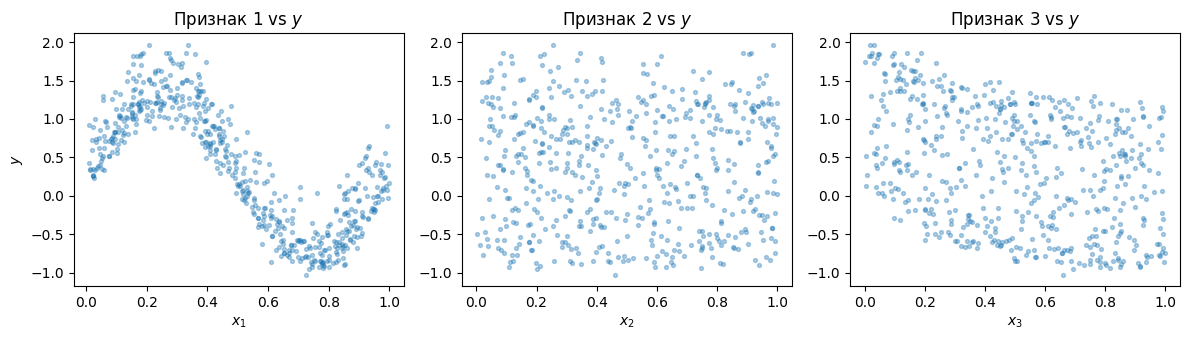

Обучение: 560, тест: 240


In [5]:
def true_g1(t): return np.sin(2 * np.pi * t)
def true_g2(t): return 0.5 * (t - 0.5) ** 2
def true_g3(t): return np.exp(-3 * t)
TRUE_G = [true_g1, true_g2, true_g3]

rng = np.random.default_rng(42)
n = 800
X = rng.uniform(0, 1, size=(n, 3))
y = true_g1(X[:, 0]) + true_g2(X[:, 1]) + true_g3(X[:, 2]) + rng.normal(0, 0.1, n)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for j, ax in enumerate(axes):
    ax.scatter(X_train[:, j], y_train, s=8, alpha=0.35)
    ax.set_xlabel(f'$x_{j+1}$')
    ax.set_ylabel('$y$' if j == 0 else '')
    ax.set_title(f'Признак {j+1} vs $y$')
plt.tight_layout()
plt.show()

print(f'Обучение: {len(y_train)}, тест: {len(y_test)}')

На графиках выше каждый признак отложен по отдельности против $y$. Для $x_1$ видна периодическая структура (синус). Для $x_2$ точки заполняют прямоугольник: слагаемое $0.5(x_2 - 0.5)^2$ меняется только от 0 до $0.125$, на фоне синуса и экспоненты в scatter это выглядит как облако. Для $x_3$ заметен спад $y$ при росте $x_3$, как у $e^{-3x_3}$.

Теперь задаём модель. В качестве базиса выберем полиномиальный базис, достаточный в данном случае: $\psi_m(t) = t^m$, $m = 1, \ldots, M$ - сначала возьмём $M = 6$.

Задача переходит в линейную относительно вектора параметров $\theta$. Каждый объект представляется в виде признакового вектора $z_i = (1, \psi_1(x_{i1}), \ldots, \psi_M(x_{i1}), \ldots, \psi_M(x_{ip}))$, а прогноз строится как $\hat y_i = z_i^T \theta$. Матрица плана $Z$ имеет размерность $n \times (1 + pM)$, а веса находятся классическим методом наименьших квадратов (МНК):

$$\hat\theta = (Z^T Z)^{-1} Z^T y$$


In [6]:
def poly_basis(t, M):
    return np.column_stack([t ** m for m in range(1, M + 1)])


def build_Z(X, M):
    n, p = X.shape
    blocks = [np.ones((n, 1))]
    for j in range(p):
        blocks.append(poly_basis(X[:, j], M))
    return np.hstack(blocks)


def fit_ols(Z, y):
    theta, _, _, _ = np.linalg.lstsq(Z, y, rcond=None)
    return theta


def predict_additive(X, theta, M):
    return build_Z(X, M) @ theta


def metrics_table(rows, title=''):
    df = pd.DataFrame(rows).set_index('model')
    if title:
        print(title)
    display(df.round(4))


M = 6
Z_train = build_Z(X_train, M)
print('Z:', Z_train.shape)

theta = fit_ols(Z_train, y_train)
y_hat_train = predict_additive(X_train, theta, M)
y_hat_test = predict_additive(X_test, theta, M)

metrics_table([
    {'model': 'train', 'RMSE': np.sqrt(mean_squared_error(y_train, y_hat_train)),
     'R2': r2_score(y_train, y_hat_train)},
    {'model': 'test', 'RMSE': np.sqrt(mean_squared_error(y_test, y_hat_test)),
     'R2': r2_score(y_test, y_hat_test)},
], 'Аддитивная модель, M=6:')


Z: (560, 19)
Аддитивная модель, M=6:


,RMSE,R2
model,,
train,0.0983,0.9837
test,0.1061,0.9808


После обучения получаем на train $R^2 \approx 0.98$, на test почти то же, переобучения почти нет. RMSE на test около 0.11 при $\sigma = 0.1$ в шуме, то есть ошибка близка к уровню шума. Вывод: при аддитивной генерации данных модель снимает основную структуру; это контрольный пример, где метод должен работать.

Далее выполним центрирование: для каждого $j$ считаем $\bar g_j$ на train, переносим в $\beta_0$. Прогнозы $\hat y$ не меняются.


сдвиги: [-0.013 -0.073 -0.685]


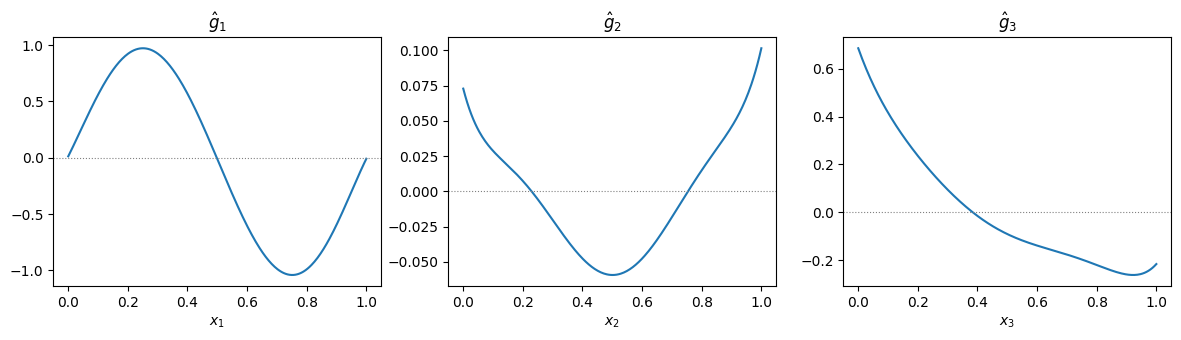

In [7]:
def component_values(X, theta, M, j):
    idx = 1 + j * M
    return build_Z(X, M)[:, idx:idx + M] @ theta[idx:idx + M]


def center_theta(X, theta, M):
    p = X.shape[1]
    offsets = np.array([np.mean(component_values(X, theta, M, j)) for j in range(p)])
    return theta, offsets


def gj_curve(theta, M, j, p, offsets, t=None):
    if t is None:
        t = np.linspace(0, 1, 200)
    x = np.zeros((len(t), p))
    x[:, j] = t
    return component_values(x, theta, M, j) - offsets[j]


theta, offsets = center_theta(X_train, theta, M)
print('сдвиги:', np.round(offsets, 3))

t = np.linspace(0, 1, 300)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for j, ax in enumerate(axes):
    ax.plot(t, gj_curve(theta, M, j, 3, offsets, t))
    ax.axhline(0, color='gray', ls=':', lw=0.8)
    ax.set_title(f'$\\hat g_{j+1}$')
    ax.set_xlabel(f'$x_{j+1}$')
plt.tight_layout()
plt.show()


После центрирования получаем, что $\hat g_1$ похож на синус, $\hat g_2$ на параболу с минимумом около $x_2=0.5$, $\hat g_3$ спадает при росте $x_3$. Формы схожи с истинными $g_j$, поэтому можно сделать вывод, что данные аддитивны и $M=6$ достаточно.

Теперь сравним с линейной моделью и с полиномом 2-й степени ($x_j x_k$). Смотрим RMSE и $R^2$ на test.


Сравнение (test):


,params,RMSE,R2
model,,,
linear,4,0.4733,0.6176
additive,19,0.1061,0.9808
poly deg=2,9,0.4605,0.6381


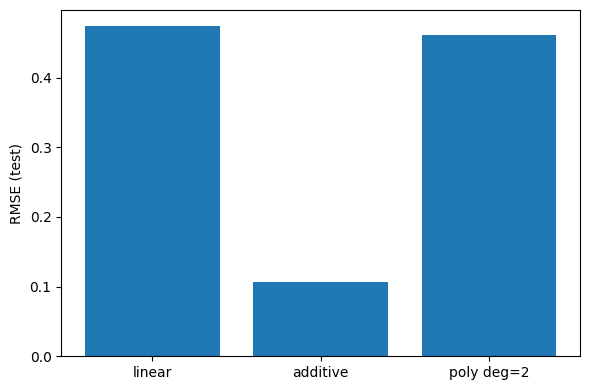

In [8]:
lin = LinearRegression().fit(X_train, y_train)

poly = PolynomialFeatures(degree=2, include_bias=False)
Xtr_poly = poly.fit_transform(X_train)
Xte_poly = poly.transform(X_test)
full = LinearRegression().fit(Xtr_poly, y_train)

rows = []
for name, yte_p, n_par in [
    ('linear', lin.predict(X_test), 4),
    ('additive', y_hat_test, 1 + 3 * M),
    ('poly deg=2', full.predict(Xte_poly), Xtr_poly.shape[1]),
]:
    rows.append({'model': name, 'params': n_par,
                 'RMSE': np.sqrt(mean_squared_error(y_test, yte_p)),
                 'R2': r2_score(y_test, yte_p)})

metrics_table(rows, 'Сравнение (test):')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([r['model'] for r in rows], [r['RMSE'] for r in rows])
ax.set_ylabel('RMSE (test)')
plt.tight_layout()
plt.show()

Линейная модель даёт $R^2 \approx 0.62$ на test, RMSE в несколько раз больше, чем у аддитивной. Полином 2-й степени: $R^2 \approx 0.64$. При этом, аддитивная модель даёт ещё и кривые $\hat g_j$ по каждому признаку. Функция здесь - сумма нелинейных $g_j(x_j)$, поэтому аддитивная модель подходит по структуре лучше.

Далее перебираем $M = 1, \ldots, 12$, смотрим RMSE на train и test.

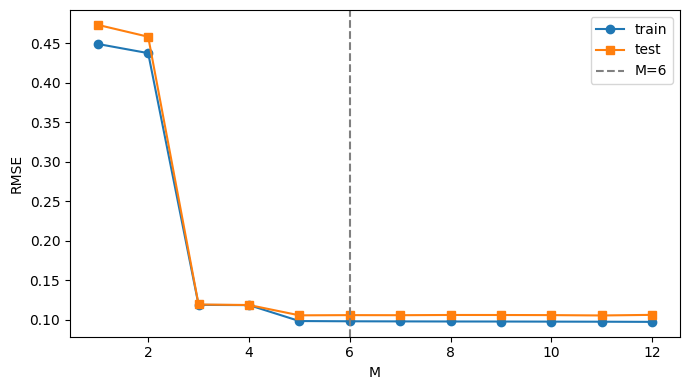

min test RMSE: 0.10564206256550257 при M = 11


In [9]:
M_values = list(range(1, 13))
train_rmse, test_rmse = [], []

for M_cur in M_values:
    th = fit_ols(build_Z(X_train, M_cur), y_train)
    th, _ = center_theta(X_train, th, M_cur)
    train_rmse.append(np.sqrt(mean_squared_error(y_train, predict_additive(X_train, th, M_cur))))
    test_rmse.append(np.sqrt(mean_squared_error(y_test, predict_additive(X_test, th, M_cur))))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(M_values, train_rmse, 'o-', label='train')
ax.plot(M_values, test_rmse, 's-', label='test')
ax.axvline(M, ls='--', color='gray', label=f'M={M}')
ax.set_xlabel('M')
ax.set_ylabel('RMSE')
ax.legend()
plt.tight_layout()
plt.show()

print('min test RMSE:', min(test_rmse), 'при M =', M_values[int(np.argmin(test_rmse))])

По графику подбора $M$ заметно, что основной выигрыш происходит при переходе $M=2 \to 3$ (RMSE падает примерно на 0.34). При $M=1 \to 2$ почти нет изменений. При $M \geq 3$ test RMSE уже около $0.11$–$0.12$ и дальше почти не меняется, минимум около 0.1056 при $M=11$. Берём $M=6$: test RMSE 0.1061, чуть хуже минимума, зато меньше параметров - 19.



Затем сравниваем $\hat g_j$ с истинными $g_j$ (обе кривые центрируем на train).


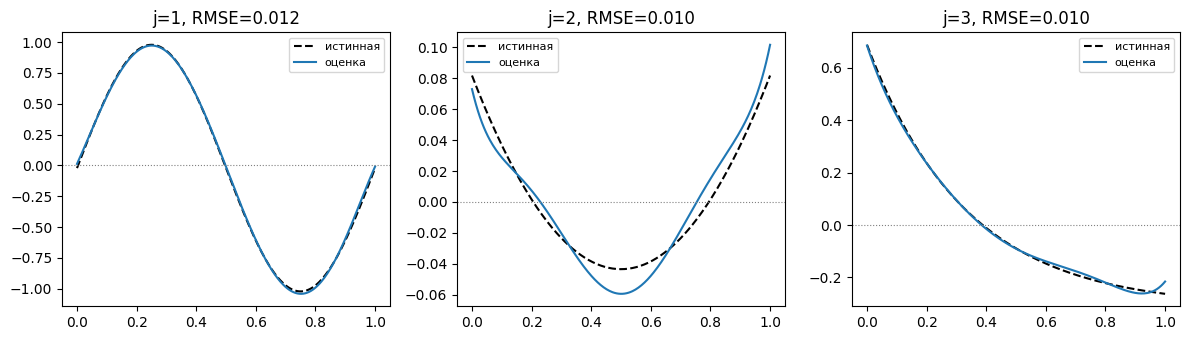

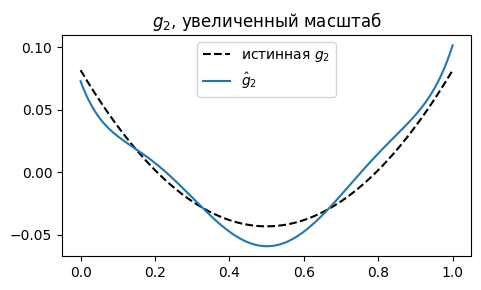

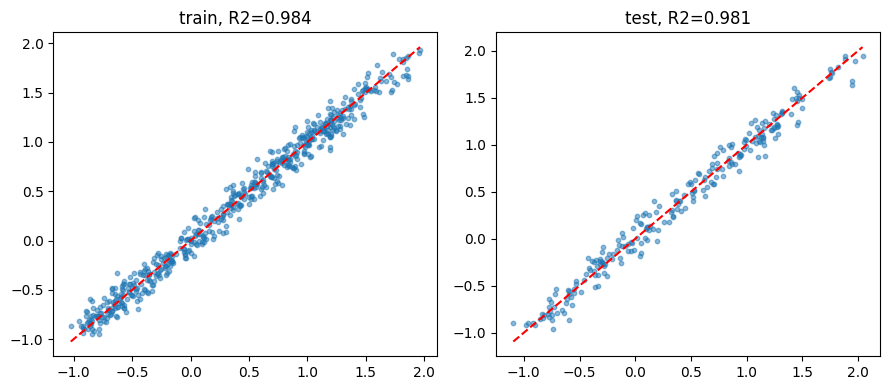

In [10]:
t = np.linspace(0, 1, 300)

def true_g_centered(j, t):
    mu = np.mean(TRUE_G[j](X_train[:, j]))
    return TRUE_G[j](t) - mu

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for j, ax in enumerate(axes):
    true_c = true_g_centered(j, t)
    est_c = gj_curve(theta, M, j, 3, offsets, t)
    rmse_j = np.sqrt(np.mean((est_c - true_c) ** 2))
    ax.plot(t, true_c, 'k--', label='истинная')
    ax.plot(t, est_c, label='оценка')
    ax.axhline(0, color='gray', ls=':', lw=0.8)
    ax.set_title(f'j={j+1}, RMSE={rmse_j:.3f}')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5, 3))
j = 1
ax.plot(t, true_g_centered(j, t), 'k--', label='истинная $g_2$')
ax.plot(t, gj_curve(theta, M, j, 3, offsets, t), label='$\\hat g_2$')
ax.set_title('$g_2$, увеличенный масштаб')
ax.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, y_true, y_pred, split in [
    (axes[0], y_train, y_hat_train, 'train'),
    (axes[1], y_test, y_hat_test, 'test'),
]:
    ax.scatter(y_true, y_pred, s=10, alpha=0.5)
    lim = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lim, lim, 'r--')
    ax.set_title(f'{split}, R2={r2_score(y_true, y_pred):.3f}')
plt.tight_layout()
plt.show()


На этом сравнении $\hat g_j$ близки к истинным $g_j$. Здесь компоненты восстанавливаются неплохо: модель совпадает со структурой данных.



Переходим ко второму источнику - неаддитивная синтетика:
1. $y = \sin(2\pi(x_1 + x_2)) + 0.5\, x_3 + \varepsilon$;
2. $y = x_1 x_2 + x_3 + \varepsilon$.

800 точек, 70/30. Сравниваем аддитивную модель, линейную и полином 3-й степени.


In [11]:
def run_nonadditive(gen_func, title, seed=7):
    rng = np.random.default_rng(seed)
    X = rng.uniform(0, 1, (800, 3))
    y = gen_func(X, rng)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0)

    M_na = 8
    th = fit_ols(build_Z(Xtr, M_na), ytr)
    th, _ = center_theta(Xtr, th, M_na)

    lin = LinearRegression().fit(Xtr, ytr)
    pf = PolynomialFeatures(degree=3, include_bias=False)
    Xtr_p = pf.fit_transform(Xtr)
    Xte_p = pf.transform(Xte)
    full = LinearRegression().fit(Xtr_p, ytr)

    rows = []
    for name, pte in [
        ('additive', predict_additive(Xte, th, M_na)),
        ('linear', lin.predict(Xte)),
        ('poly deg=3', full.predict(Xte_p)),
    ]:
        rows.append({'model': name,
                     'RMSE': np.sqrt(mean_squared_error(yte, pte)),
                     'R2': r2_score(yte, pte)})
    metrics_table(rows, title)
    return Xtr, ytr, rows


def gen_sin_sum(X, rng):
    return np.sin(2 * np.pi * (X[:, 0] + X[:, 1])) + 0.5 * X[:, 2] + rng.normal(0, 0.1, len(X))

def gen_product(X, rng):
    return X[:, 0] * X[:, 1] + X[:, 2] + rng.normal(0, 0.08, len(X))

res1 = run_nonadditive(gen_sin_sum, 'sin(2pi(x1+x2)) + 0.5 x3')
res2 = run_nonadditive(gen_product, 'x1*x2 + x3')


sin(2pi(x1+x2)) + 0.5 x3


,RMSE,R2
model,,
additive,0.7538,0.0191
linear,0.7504,0.0279
poly deg=3,0.5542,0.4697


x1*x2 + x3


,RMSE,R2
model,,
additive,0.1258,0.8897
linear,0.1220,0.8962
poly deg=3,0.0836,0.9513


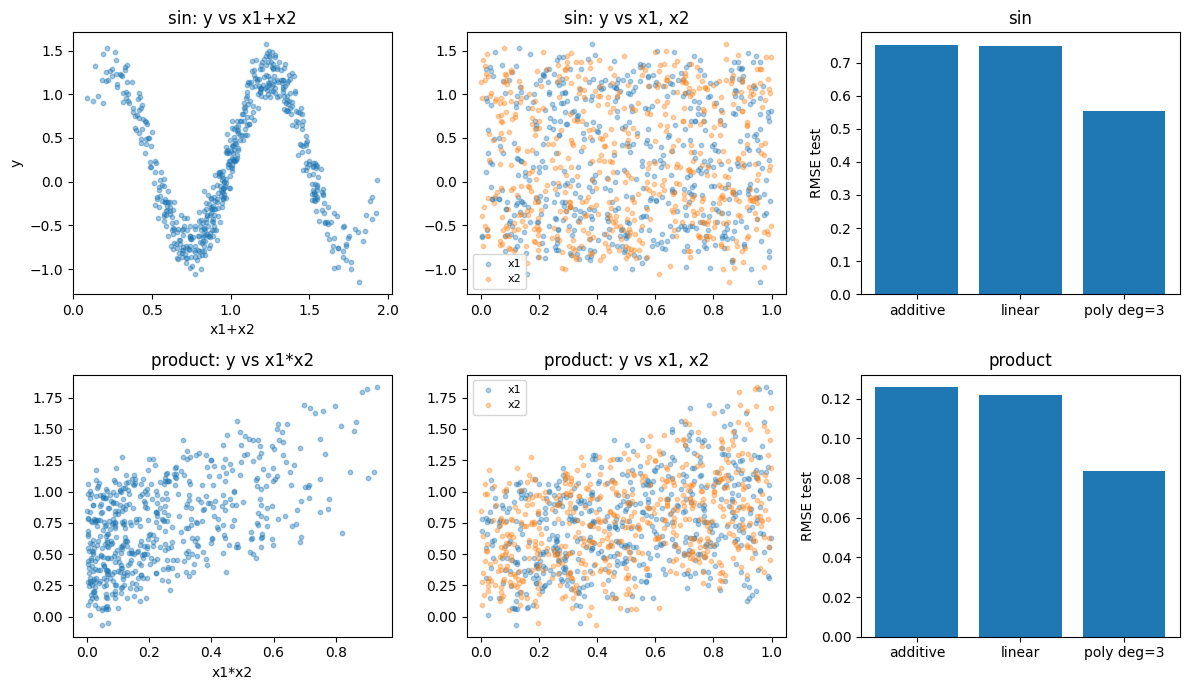

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

Xtr1, ytr1, rows1 = res1
s = Xtr1[:, 0] + Xtr1[:, 1]
axes[0, 0].scatter(s, ytr1, s=10, alpha=0.4)
axes[0, 0].set_xlabel('x1+x2')
axes[0, 0].set_ylabel('y')
axes[0, 0].set_title('sin: y vs x1+x2')

axes[0, 1].scatter(Xtr1[:, 0], ytr1, s=10, alpha=0.35, label='x1')
axes[0, 1].scatter(Xtr1[:, 1], ytr1, s=10, alpha=0.35, label='x2')
axes[0, 1].legend(fontsize=8)
axes[0, 1].set_title('sin: y vs x1, x2')

axes[0, 2].bar([r['model'] for r in rows1], [r['RMSE'] for r in rows1])
axes[0, 2].set_ylabel('RMSE test')
axes[0, 2].set_title('sin')

Xtr2, ytr2, rows2 = res2
p = Xtr2[:, 0] * Xtr2[:, 1]
axes[1, 0].scatter(p, ytr2, s=10, alpha=0.4)
axes[1, 0].set_xlabel('x1*x2')
axes[1, 0].set_title('product: y vs x1*x2')

axes[1, 1].scatter(Xtr2[:, 0], ytr2, s=10, alpha=0.35, label='x1')
axes[1, 1].scatter(Xtr2[:, 1], ytr2, s=10, alpha=0.35, label='x2')
axes[1, 1].legend(fontsize=8)
axes[1, 1].set_title('product: y vs x1, x2')

axes[1, 2].bar([r['model'] for r in rows2], [r['RMSE'] for r in rows2])
axes[1, 2].set_ylabel('RMSE test')
axes[1, 2].set_title('product')

plt.tight_layout()
plt.show()


Рассмотрим первый неаддитивный пример - верхний ряд - $\sin(2\pi(x_1+x_2)) + 0.5x_3$. Слева заметно, что $y$ vs $x_1+x_2$ даёт синусоиду; по $x_1$ или $x_2$ отдельно облако. То есть аддитивная модель ищет $g_1(x_1)+g_2(x_2)$, а не функцию от суммы. На test $R^2$ около 0.02 (additive), 0.03 (linear), 0.47 (poly3): модели не дают качественного прогноза, аддитивная - почти бесполезная. Здесь аддитивная модель неприменима.

Нижний ряд - $x_1 x_2 + x_3$. Связь видна по $x_1 x_2$; по $x_1$, $x_2$ снова облако. $R^2$ на test: additive около 0.89, linear 0.90, poly3 0.95. Аддитивная модель не идеальна, но не проваливается, так как сумма $g_1+g_2$ частично заменяет произведение.

Переходим к датасету про измерение опосумов: 101 особь, цель `totlngth` (мм), 9 числовых признаков. Категории не использовали. 75 train / 25 test. Признаки масштабируем MinMax в $[0,1]$, `totlngth` не трогаем (RMSE в мм).


In [13]:
df = pd.read_csv('data/possum.csv').dropna()
print('N =', df.shape[0])

TARGET = 'totlngth'
FEATURES = ['age', 'hdlngth', 'skullw', 'taill', 'footlgth', 'earconch', 'eye', 'chest', 'belly']

X_raw = df[FEATURES].values.astype(float)
y_poss = df[TARGET].values.astype(float)

scaler = MinMaxScaler()
X_poss = scaler.fit_transform(X_raw)

X_ptr, X_pte, y_ptr, y_pte = train_test_split(X_poss, y_poss, test_size=0.25, random_state=1)
p_poss = len(FEATURES)
print('train', len(y_ptr), 'test', len(y_pte))

print('corr с totlngth:')
print(df[FEATURES].corrwith(df[TARGET]).sort_values(ascending=False).round(3))


N = 101
train 75 test 26
corr с totlngth:
hdlngth     0.670
taill       0.564
chest       0.556
skullw      0.506
belly       0.501
footlgth    0.483
age         0.268
eye         0.247
earconch    0.181
dtype: float64


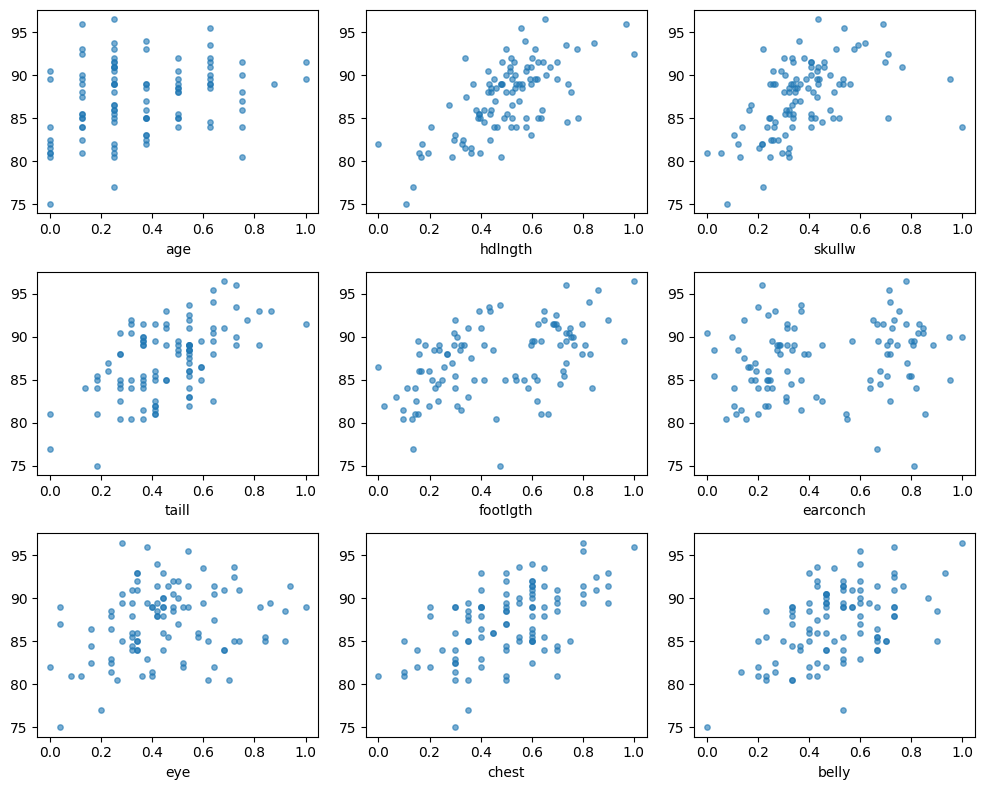

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(10, 8))
for j, (ax, name) in enumerate(zip(axes.ravel(), FEATURES)):
    ax.scatter(X_poss[:, j], y_poss, s=15, alpha=0.6)
    ax.set_xlabel(name)
plt.tight_layout()
plt.show()


Корреляции с `totlngth`: сильнее `hdlngth` (0.67), `taill`, `chest` (около 0.56), `skullw`, `belly`, `footlgth` (0.48-0.51), слабее `age`, `eye`, `earconch`. Признаки одной особи коррелируют между собой, поэтому $\hat g_j$ нельзя трактовать как независимые «эффекты» признаков.

Для аддитивной модели выберем параметры: $M=4$, ridge $\alpha=0.5$ (37 параметров при 75 точках train). Сравниваем с линейной и poly2 + ridge.


In [15]:
def fit_ridge(Z, y, alpha=0.5):
    return Ridge(alpha=alpha, fit_intercept=False).fit(Z, y).coef_


M_poss = 4
theta_p = fit_ridge(build_Z(X_ptr, M_poss), y_ptr)
theta_p, off_p = center_theta(X_ptr, theta_p, M_poss)

yhat_ptr = predict_additive(X_ptr, theta_p, M_poss)
yhat_pte = predict_additive(X_pte, theta_p, M_poss)

lin_p = LinearRegression().fit(X_ptr, y_ptr)
poly_p = PolynomialFeatures(degree=2, include_bias=False)
Xpp_tr = poly_p.fit_transform(X_ptr)
Xpp_te = poly_p.transform(X_pte)
full_p = Ridge(alpha=1.0).fit(Xpp_tr, y_ptr)

rows_p = []
for name, ytr_p, yte_p, npar in [
    ('linear', lin_p.predict(X_ptr), lin_p.predict(X_pte), p_poss + 1),
    ('additive+ridge', yhat_ptr, yhat_pte, 1 + p_poss * M_poss),
    ('poly2+ridge', full_p.predict(Xpp_tr), full_p.predict(Xpp_te), Xpp_tr.shape[1]),
]:
    rows_p.append({'model': name, 'params': npar,
                   'RMSE_test': np.sqrt(mean_squared_error(y_pte, yte_p)),
                   'R2_test': r2_score(y_pte, yte_p)})

metrics_table(rows_p, 'Опосумы (test):')


Опосумы (test):


,params,RMSE_test,R2_test
model,,,
linear,10,2.2434,0.7914
additive+ridge,37,1.9430,0.8435
poly2+ridge,54,2.5162,0.7376


Получаем, что аддитивная модель с ridge даёт RMSE около 1.9 мм, $R^2$ около 0.84 на test. Линейная модель хуже (RMSE около 2.2 мм), poly2 с ridge переобучается (хуже на test при 54 параметрах). Аддитивная модель лучше, но не идеальна: возможно, есть взаимодействия или более сложные зависимости, которые она не снимает. Далее посмотрим, как RMSE меняется при $M=1, \ldots,8$ и какие формы $g_j$ получаются.

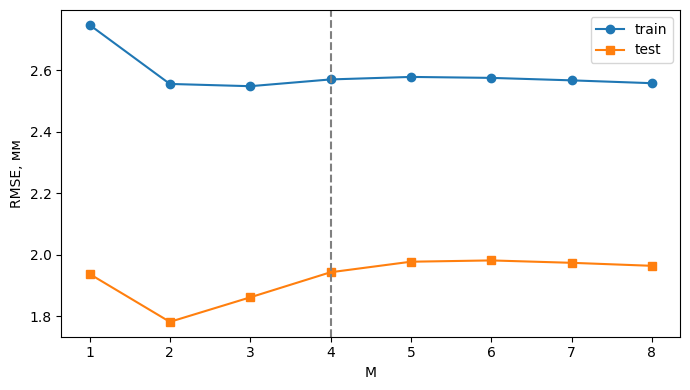

In [16]:
M_grid = range(1, 9)
tr_rmse, te_rmse = [], []
for M_cur in M_grid:
    th = fit_ridge(build_Z(X_ptr, M_cur), y_ptr)
    th, _ = center_theta(X_ptr, th, M_cur)
    tr_rmse.append(np.sqrt(mean_squared_error(y_ptr, predict_additive(X_ptr, th, M_cur))))
    te_rmse.append(np.sqrt(mean_squared_error(y_pte, predict_additive(X_pte, th, M_cur))))

plt.figure(figsize=(7, 4))
plt.plot(list(M_grid), tr_rmse, 'o-', label='train')
plt.plot(list(M_grid), te_rmse, 's-', label='test')
plt.axvline(M_poss, ls='--', color='gray')
plt.xlabel('M')
plt.ylabel('RMSE, мм')
plt.legend()
plt.tight_layout()
plt.show()


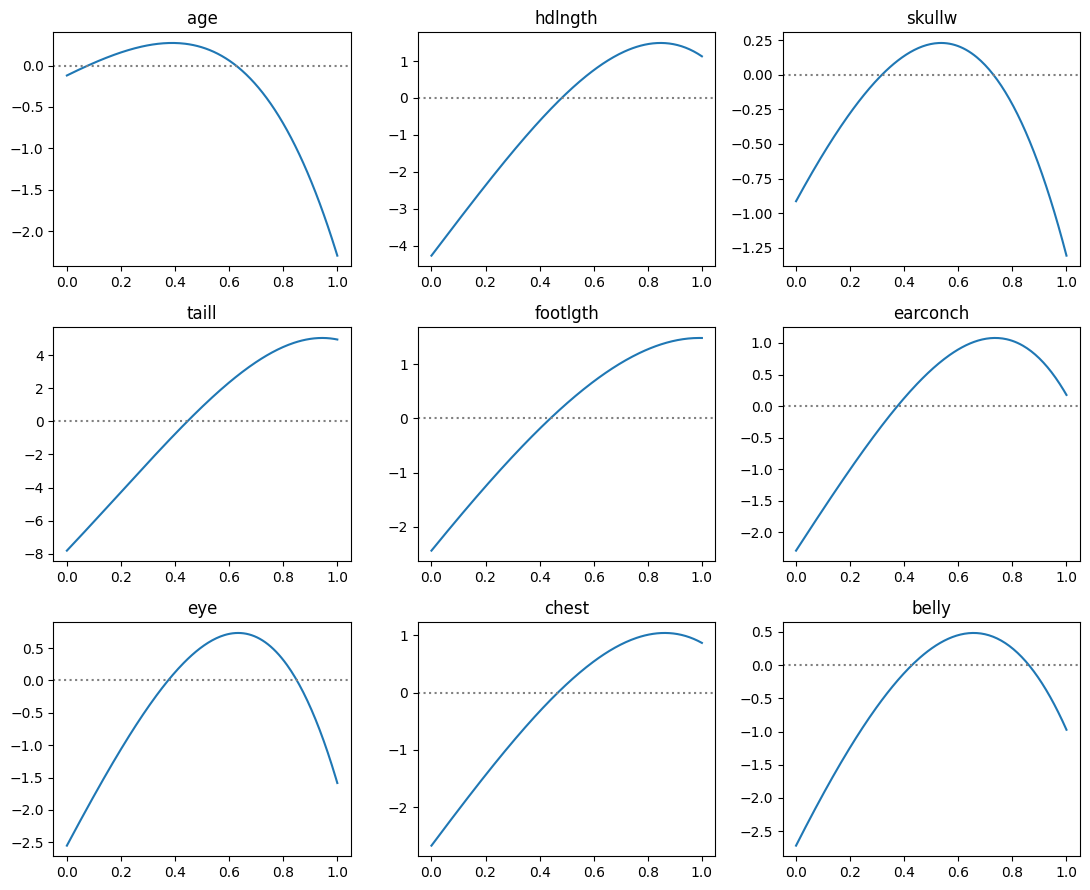

In [17]:
t = np.linspace(0, 1, 200)
fig, axes = plt.subplots(3, 3, figsize=(11, 9))
for j, (ax, name) in enumerate(zip(axes.ravel(), FEATURES)):
    ax.plot(t, gj_curve(theta_p, M_poss, j, p_poss, off_p, t))
    ax.axhline(0, color='gray', ls=':')
    ax.set_title(name)
plt.tight_layout()
plt.show()


Из графиков можно отметить лидера по размаху кривых - `taill` (около 13 мм, рост при увеличении хвоста). `hdlngth` около 6 мм, форма обратно-U-образная, ближе к концу интревала значение начинает уменьшаться. `footlgth`, `chest` имеют размах около 4 мм и по фомре близки к `hdlngth`. Остальные признаки дают кривые с размахом около 2 мм и имеют более резкие параболические формы с центром ближе к 0.5.

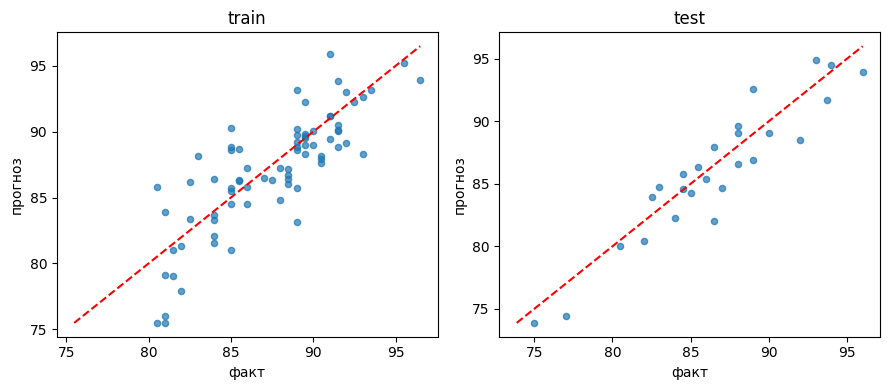

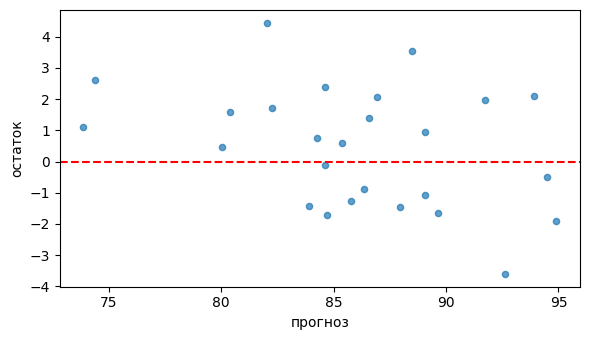

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, y_true, y_pred, title in [
    (axes[0], y_ptr, yhat_ptr, 'train'),
    (axes[1], y_pte, yhat_pte, 'test'),
]:
    ax.scatter(y_true, y_pred, s=20, alpha=0.7)
    mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--')
    ax.set_xlabel('факт')
    ax.set_ylabel('прогноз')
    ax.set_title(title)
plt.tight_layout()
plt.show()

residuals = y_pte - yhat_pte
plt.figure(figsize=(6, 3.5))
plt.scatter(yhat_pte, residuals, s=20, alpha=0.7)
plt.axhline(0, color='r', ls='--')
plt.xlabel('прогноз')
plt.ylabel('остаток')
plt.tight_layout()
plt.show()


Проверка остатков на test: явного тренда остатков от прогноза нет, что согласуется с приемлемой спецификацией. RMSE около 2 мм при средней длине тела около 90 мм; выборка test мала ($n=26$), отдельные выбросы на диаграммах ожидаемы.

Таким образом аддитивная модель по мотивам теоремы Колмогорова:

1. На аддитивных данных восстанавливает структуру с высокой точностью (R² ≈ 0.98), компоненты $g_j$ близки к истинным функциям.

2. На неаддитивных данных может значительно проигрывать специализированным моделям: при $\sin(2\pi(x_1+x_2))$ R² ≈ 0.02, что почти бесполезно; при произведении $x_1 x_2$ даёт R² ≈ 0.89, хотя poly3 достигает 0.95.

3. Преимущества: даёт интерпретируемые одномерные компоненты $g_j$, требует меньше параметров чем полиномиальные модели полной степени, автоматически обучается нелинейным зависимостям.

4. На реальных данных (опосумы, n=75): RMSE ≈ 1.9 мм, R² ≈ 0.84 на test - лучше чем линейная модель и poly2+ridge, но не идеально, указывая на наличие неучтённых взаимодействий.

5. При малых выборках требует осторожности с выбором $M$ (баланс смещения и дисперсии) и критического отношения к интерпретации $g_j$ из-за мультиколлинеарности признаков.